In [1]:
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt
import json

In [11]:
def first_order(t, q_e, k):
    return q_e * (1 - np.exp(-k * t))

def second_order(t, q_e, k):
    return (q_e**2 * k * t) / (1 + q_e * k * t)

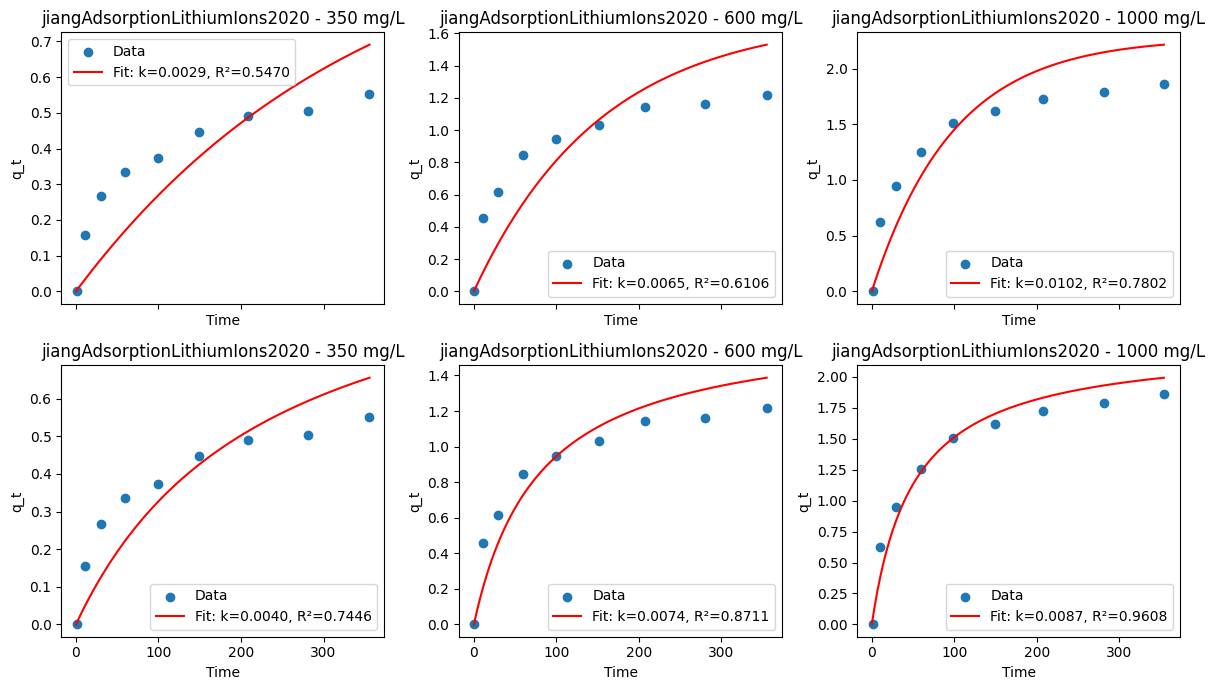

In [32]:
with open('isotherm_kinetics.json', 'r') as f:
    data = json.load(f)
    for paper, value in data.items():
        fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharex=True)
        for type in ["First Order", "Second Order"]:
            for i,kinetics in enumerate(value['kinetics']):
                q_e = np.interp(kinetics['C_e'], value['isotherm']['C_e'], value['isotherm']['q_e'])

                t = np.array(kinetics['time'])
                q_t = np.array(kinetics['q_t'])

                t = t[t < 400]
                q_t = q_t[:t.size]
                ax = axes.flatten()[i + (0 if type == "First Order" else 3)]
                def model(t, k):
                    if type == "Second Order":
                        return second_order(t, q_e, k)

                    else:
                        return first_order(t, q_e, k)
                popt, pcov = curve_fit(model, t, q_t, p0=[0.1])
                yhat = model(t, *popt)
                r2 = 1.0 - np.sum((q_t - yhat)**2) / np.sum((q_t - q_t.mean())**2)
                
                ax.scatter(t, q_t, label='Data')
                t_fit = np.linspace(0, max(t), 100)
                ax.plot(t_fit, model(t_fit, *popt), 'r-', label=f'Fit: k={popt[0]:.4f}, R²={r2:.4f}')
                ax.set_xlabel('Time')
                ax.set_ylabel('q_t')
                ax.set_title(f"{paper} - {kinetics['C_e']} mg/L")
                ax.legend()
    plt.tight_layout()